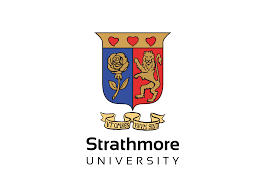

<p style="text-align: center;"><font size="5"> <font color = "blue"> Predicting Type 2 Diabetes using Neural Networks </p>

<p style="text-align: center;"><font size="4">Samuel Irungu Kigotho</font></p>
<p style="text-align: center;"><font size="4">Adm No: 169124</font></p>
<p style="text-align: center;"><font size="4">Assigment: Neural Networks</font></p>
<p style="text-align: center;"><font size="4">DSA 8401: Applied Machine Learning</font></p>
<p style="text-align: center;"><font size="4">Master in Data Science and Analytic</font></p>

## Background information 

<p style='text-align: justify;'> Neural networks are computational models inspired by the human brain's structure and functioning. They consist of interconnected nodes, or "neurons," organized into layers. The key components of neural networks include: Typically composed of an input layer, one or more hidden layers, and an output layer. Each layer contains multiple neurons that process data. Connections between neurons have associated weights, which are adjusted during training to minimize errors. Biases are additional parameters that help shift the activation function. Neurons use activation functions (like sigmoid, ReLU, or tanh) to determine whether to activate based on the input they receive. These functions introduce non-linearity, allowing networks to learn complex patterns.Neural networks learn through a process called backpropagation, where the model adjusts weights based on the error of predictions compared to actual outcomes. This is typically done using gradient descent optimization techniques.Neural networks are widely used in various fields, including image and speech recognition, natural language processing, and autonomous systems.
The development of deep learning, a subset of machine learning that employs deep neural networks with many layers, has significantly advanced the capabilities and applications of neural networks in recent years. <p> 

## Summary of the dataset

<p style='text-align: justify;'>
The data used for this analysis was collected and provided by the "National Institute of Diabetes and Digestive and Kidney Diseases" as part of the Pima Indians Diabetes Database. The dataset comprises instances from a larger database, with specific constraints. All patients included in the dataset belong to the Pima Indian heritage, which is a subgroup of Native Americans. <p>

## Data Description 

<p style='text-align: justify;'>
First the data is publicly accessible on the Kaggle website (https://www.kaggle.com/uciml/pima-indians-diabetes-database) and 
serves as an open-source dataset comprising records of female patients. The dataset encompasses a total of 768 
cases, with each case representing a female participant from the Pima Indigenous community. Within each 
case, there is a binary indicator, indicating whether the individual is non-diabetic (0) or diabetic (1). Other features included in the data are as shown in the table below.<p>

|Attribute | Description |
|:----------|------------:|
|Pregnancies:|Number of times a Pima Indigenous female got pregnant |
|Glucose:|In an oral glucose tolerance test, plasma glucose concentration measured over 2 hours.|
|Blood Pressure:|Diastolic blood pressure (mm Hg)|
|Skin Thickness:|Thickness of Triceps skin fold (mm)|
|Insulin:|2-Hour serum insulin (mu U/ml)|
|BMI:|Body Mass Index (weight in kg/(height in m)²)|
|Diabetes Pedigree Function:|Diabetes pedigree function| 
|Age:|Age in years |
|Outcome:|0 means that a female does not have Type II diabetes, and a 1 indicates the participant has Type II diabetes|



**Pregnancies:** Number of times a Pima Indigenous female got pregnant.<br>
**Glucose Level:** Plasma glucose concentration over 2 hours in an oral glucose tolerance test. <br>
**Blood pressure:** Blood pressure refers to the force exerted by the blood as it circulates through the body's 
cardiovascular system. It plays a crucial role in maintaining proper circulation. <br>
**Skin Thickness:** Triceps skinfold thickness, measured in **millimeters (mm)** within the dataset, is a metric that offers 
a reliable estimate of both obesity and body fat distribution. <br>
**Insulin:** 
In the Pima Indigenous community, the metric used to measure the level of insulin in the blood after a two-hour 
period is denoted as **"mu U/ml" (micro-units per milliliter)**. In the context of the dataset, the variable labeled 'Insulin' 
represents the two-hour serum insulin level. By analyzing an individual's insulin levels following a meal, it is 
possible to identify the presence of a metabolic disorder and determine if there is a defect in islet function, both of 
which are associated with diabetes. Insulin, a peptide hormone, is primarily produced by the beta cells of the 
pancreatic islets and serves as the body's main anabolic hormone. Its role involves regulating the metabolism of 
carbohydrates, fats, and proteins by facilitating the absorption of glucose from the bloodstream into the liver, adipose 
tissue (fat), and skeletal muscle cells.<br> 
**BMI:** Body mass index (BMI), a measure of obesity and health, is commonly used in statistical analysis. The degree 
of obesity cannot be judged directly by the absolute value of the weight, and it is naturally related to height. So, 
BMI is defined as the body mass divided by the square of the body height.<br>
**Diabetes Pedigree Function:** The term used for this variable is DBF, which indicates the probability of developing 
diabetes depending on one's familial background (Joshi & Dhakal, 2021, 1-7). <br>
**Age:** Age (years) the range in the dataset is from 21 to 81. <br>
**Outcome:** Classification variable where 0 means that a female does not have Type II diabetes, and a 1 indicates the 
participant has Type II diabetes. <p>

## Import Libraries 

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from keras.callbacks import EarlyStopping
from keras.optimizers import SGD
from keras.layers import Dropout
from keras.regularizers import l2

In [12]:
import warnings
warnings.filterwarnings("ignore")

## Data Importation 

In [2]:
# Read data
data = pd.read_csv("diabetes.csv")

## Data Exploration and Visualization

In [3]:
data.head(),

(   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0            6      148             72             35        0  33.6   
 1            1       85             66             29        0  26.6   
 2            8      183             64              0        0  23.3   
 3            1       89             66             23       94  28.1   
 4            0      137             40             35      168  43.1   
 
    DiabetesPedigreeFunction  Age  Outcome  
 0                     0.627   50        1  
 1                     0.351   31        0  
 2                     0.672   32        1  
 3                     0.167   21        0  
 4                     2.288   33        1  ,)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


As decribed above the data contains 768 entries with 9 columns as shown above.

First of all, we are going to check the summary statistics for the numeric variables in the dataset. This involves performing univariate exploratory data analysis (EDA) for the feature variables.

In [7]:
data.describe(),

(       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
 count   768.000000  768.000000     768.000000     768.000000  768.000000   
 mean      3.845052  120.894531      69.105469      20.536458   79.799479   
 std       3.369578   31.972618      19.355807      15.952218  115.244002   
 min       0.000000    0.000000       0.000000       0.000000    0.000000   
 25%       1.000000   99.000000      62.000000       0.000000    0.000000   
 50%       3.000000  117.000000      72.000000      23.000000   30.500000   
 75%       6.000000  140.250000      80.000000      32.000000  127.250000   
 max      17.000000  199.000000     122.000000      99.000000  846.000000   
 
               BMI  DiabetesPedigreeFunction         Age     Outcome  
 count  768.000000                768.000000  768.000000  768.000000  
 mean    31.992578                  0.471876   33.240885    0.348958  
 std      7.884160                  0.331329   11.760232    0.476951  
 min      0.000000   

The dataset shows a broad range of values across various health indicators. <br>
The average number of pregnancies is 3.85, with glucose levels averaging around 120.89 mg/dL. <br> 
Blood pressure and BMI have means of 69.11 mm Hg and 31.99 kg/m², respectively. <br>
Notably, some entries have zero values which can be observed by the minimum values , likely due to data entry errors or missing measurements. <br>
These anomalies can distort statistical analyses and in our case.<br> 
    To enhance the accuracy, i will be replacing zero values in, <span style="background-color: silver"> **glucose** </span>, <span style="background-color: silver"> **BMI** </span>, <span style="background-color: silver"> **blood pressure**</span>, and <span style="background-color: silver"> **skin thickness**</span> with means adjusted for age.


## Number of zeros in each Column 

In [8]:
# Check which columns that have the value zero in their rows
zeros = (data == 0).sum()
print("Number of zero values per column:")
print(zeros)

Number of zero values per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


We calculate the means for each of the above columns i.e  <span style="background-color: silver"> **glucose** </span>, <span style="background-color: silver"> **BMI** </span>, <span style="background-color: silver"> **blood pressure**</span>, and <span style="background-color: silver"> **skin thickness**</span> in respect to each age group and replace missing values with the average of the corresponding age range group

In [10]:
# Divide the data into groups based on age range
age_groups = pd.cut(data['Age'], bins=3)  

In [11]:
# Calculate the counts in each bin
age_group_counts = age_groups.value_counts().sort_index()
age_group_counts

(20.94, 41.0]    596
(41.0, 61.0]     147
(61.0, 81.0]      25
Name: Age, dtype: int64

In [12]:
# Calculate the average of Insulin, Glucose, BMI, and Skin Thickness for each age range group
insulin_mean_by_age = data.groupby(age_groups)['Insulin'].transform('mean')
glucose_mean_by_age = data.groupby(age_groups)['Glucose'].transform('mean')
bmi_mean_by_age = data.groupby(age_groups)['BMI'].transform('mean')
skin_thickness_mean_by_age = data.groupby(age_groups)['SkinThickness'].transform('mean')
blood_pressure_mean_by_age = data.groupby(age_groups)['BloodPressure'].transform('mean')

In [13]:
# Replace missing values of Insulin, Glucose, BMI, and Skin Thickness with the average of the corresponding age range group
data['Insulin'] = data['Insulin'].mask(data['Insulin'] == 0, insulin_mean_by_age)
data['Glucose'] = data['Glucose'].mask(data['Glucose'] == 0, glucose_mean_by_age)
data['BMI'] = data['BMI'].mask(data['BMI'] == 0, bmi_mean_by_age)
data['SkinThickness'] = data['SkinThickness'].mask(data['SkinThickness'] == 0, skin_thickness_mean_by_age)
data['BloodPressure'] = data['BloodPressure'].mask(data['BloodPressure'] == 0, blood_pressure_mean_by_age)

# Verify if the values were correctly replaced
data.describe(),  

(       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
 count   768.000000  768.000000     768.000000     768.000000  768.000000   
 mean      3.845052  121.662029      72.185362      26.449627  117.784467   
 std       3.369578   30.437485      12.153626       9.828745   94.273138   
 min       0.000000   44.000000      24.000000       7.000000    9.600000   
 25%       1.000000   99.750000      64.000000      20.000000   80.625839   
 50%       3.000000  117.000000      72.000000      23.000000   80.625839   
 75%       6.000000  140.250000      80.000000      32.000000  127.250000   
 max      17.000000  199.000000     122.000000      99.000000  846.000000   
 
               BMI  DiabetesPedigreeFunction         Age     Outcome  
 count  768.000000                768.000000  768.000000  768.000000  
 mean    32.446061                  0.471876   33.240885    0.348958  
 std      6.877122                  0.331329   11.760232    0.476951  
 min     18.200000   

In [14]:
# Check if the columns have any zero values in their rows
zeros = (data == 0).sum()
print("Number of zero values per column:")
print(zeros)

Number of zero values per column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


We see that there are no zeros in the columns except the Outcome and the pregnancies which is expected give that there can be zero pregnancies.

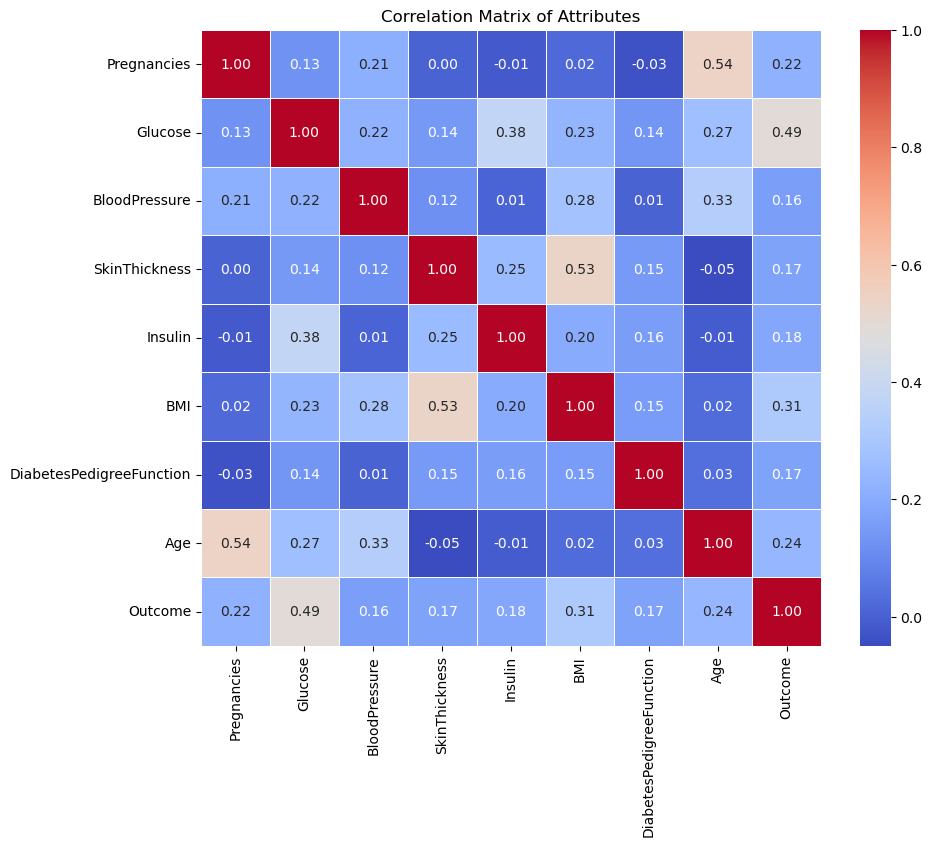

In [15]:
#Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Attributes')
plt.show()

# Data Modelling and evaluation

## Create a model using the sequetial API trying different number of layers (1-5) and different number of neurons per layer.

Create Models with Varying Layers and Neurons
We'll create a function to build models with a variable number of layers and neurons.

In [5]:
def create_model(layers, neurons):
    model = Sequential()
    model.add(Dense(neurons, input_dim=data.shape[1]-1, activation='relu'))  # Input layer
    for _ in range(1, layers):
        model.add(Dense(neurons, activation='relu'))  # Hidden layers
    model.add(Dense(1, activation='sigmoid'))  # Output layer
    return model

## Train the different models and evaluate. Analize which one perform better.


In [10]:
# Save x & y variables
y = data['Outcome']
x = data.drop(['Outcome'], axis=1)

In [13]:
# splitting dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=42)

results = []
for layers in range(1, 6):
    for neurons in [5, 10, 20]:  # Different neuron configurations
        model = create_model(layers, neurons)
        model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])
        model.fit(x_train, y_train, epochs=50, batch_size=10, verbose=0)
        
        # Evaluate the model
        y_pred = (model.predict(x_test) > 0.5).astype("int32")
        accuracy = accuracy_score(y_test, y_pred)
        results.append((layers, neurons, accuracy))

# Find the best performing model
best_model = max(results, key=lambda x: x[2])
print(f"Best Model - Layers: {best_model[0]}, Neurons: {best_model[1]}, Accuracy: {best_model[2]}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Best Model - Layers: 3, Neurons: 20, Accuracy: 0.7489177489177489


## Fine-tune Learning Rate and Batch Size

In [20]:
# Define a function to fine-tune learning rates and batch sizes
def fine_tune_model(learning_rate, batch_size):
    model = create_model(best_model[0], best_model[1])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(x_train, y_train, epochs=100, batch_size=batch_size, validation_split=0.1, callbacks=[early_stopping], verbose=0)
    accuracy = model.evaluate(x_test, y_test, verbose=0)[1]
    return accuracy


# Define the range of learning rates
learning_rate_start = 0.0001  # Starting value
learning_rate_end = 0.1        # Ending value
num_samples = 10                # Number of samples to test

# Generate learning rates within the specified range
learning_rates = np.linspace(learning_rate_start, learning_rate_end, num_samples)

# Test different learning rates and batch sizes
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [5, 10, 20]
best_accuracy = 0
best_hyperparams = (0, 0)

for lr in learning_rates:
    for bs in batch_sizes:
        accuracy = fine_tune_model(lr, bs)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_hyperparams = (lr, bs)

print(f"Best Learning Rate: {best_hyperparams[0]}, Best Batch Size: {best_hyperparams[1]}, Accuracy: {best_accuracy}")

Best Learning Rate: 0.01, Best Batch Size: 5, Accuracy: 0.7316017150878906


## Save the best model and hyperparameters

In [21]:
import joblib

# Save the best model
model.save('best_diabetes_model.h5')

# Save the hyperparameters
joblib.dump(best_hyperparams, 'best_hyperparameters.pkl')

['best_hyperparameters.pkl']

## Compare Optimizers
We can compare the Adam optimizer with another optimizer, such as SGD with momentum.

In [24]:
def compare_optimizers(optimizer):
    model = create_model(best_model[0], best_model[1])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=50, batch_size=best_hyperparams[1], verbose=0)
    accuracy = model.evaluate(x_test, y_test, verbose=0)[1]
    return accuracy

adam_accuracy = compare_optimizers(Adam(best_hyperparams[0]))
sgd_accuracy = compare_optimizers(SGD(momentum=0.9))

print(f"Adam Accuracy: {adam_accuracy}, SGD Accuracy: {sgd_accuracy}")

Adam Accuracy: 0.7489177584648132, SGD Accuracy: 0.6536796689033508


## Try regularization and dropout to avoid overfitting. Analise the results

In [27]:
def create_model_with_dropout(layers, neurons, dropout_rate):
    model = Sequential()
    model.add(Dense(neurons, input_dim=data.shape[1]-1, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(dropout_rate))
    for _ in range(1, layers):
        model.add(Dense(neurons, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Evaluate the model with dropout
dropout_accuracy = []
for dropout in [0.2, 0.5]:
    model = create_model_with_dropout(best_model[0], best_model[1], dropout)
    model.compile(loss='binary_crossentropy', optimizer=Adam(best_hyperparams[0]), metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=50, batch_size=best_hyperparams[1], verbose=0)
    accuracy = model.evaluate(x_test, y_test, verbose=0)[1]
    dropout_accuracy.append((dropout, accuracy))

print(dropout_accuracy)


[(0.2, 0.7142857313156128), (0.5, 0.6536796689033508)]
